# Sales Potential Segmentation of Seasonal Customers Using Clustering

This project analyzes the sales potential of seasonal customers such as retail stores, bars, and restaurants.

The objective of the analysis is to identify groups of customers with similar characteristics based on traffic levels, refrigeration capacity,
location characteristics, and historical sales performance.

Using clustering techniques, customers are segmented into four business categories:

Gold  
Silver  
Bronze  
Iron  

These segments represent different levels of sales potential and help businesses prioritize investments, equipment allocation, and sales strategies.

## Research Question

How can clustering algorithms be used to segment seasonal customers such as stores, bars, and restaurants based on traffic levels,
refrigeration capacity, and historical sales in order to identify customers with the highest sales potential?

## Project Objectives

The main objectives of this project are:

- To explore the dataset and understand customer characteristics
- To analyze the relationship between traffic, refrigeration capacity, and sales
- To preprocess the dataset for clustering analysis
- To apply clustering algorithms to group customers with similar characteristics
- To classify customers into four sales potential segments: Gold, Silver, Bronze, and Iron
- To interpret the results from a business perspective

## Dataset Description

The dataset contains information about seasonal customers such as retail stores, bars, and restaurants.

Each row represents a customer outlet and includes attributes describing the environment, equipment availability, and sales performance.

The dataset contains the following variables:

Customer – Unique identifier of the outlet

City – Name of the city where the outlet operates

Channel – Type of customer channel (Hotels, QSR, etc.)

Segment – Existing traffic-based classification

Urbanicity – Level of urbanization of the area

Traffic – Estimated number of people passing near the outlet

Traffic Index – Category of traffic intensity

Equipment (Y/N) – Indicates whether a refrigerator is installed at the outlet

\# of doors – Number of refrigerator doors installed at the outlet

Sales 2025 CS – Sales volume generated by the customer

Refrigeration capacity, measured by the number of refrigerator doors, is an important operational factor that influences the ability of 
a customer to sell cold beverages during the summer season.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

pandas – for loading, cleaning, and exploring the dataset.

numpy – for numerical operations and array computations.

matplotlib / seaborn – for visualizing distributions, correlations, and clusters.

StandardScaler (sklearn) – to scale numeric features for clustering.

KMeans (sklearn) – to segment customers into clusters based on features.

hierarchy (scipy) – to perform and visualize hierarchical clustering.

silhouette_score (sklearn) – to evaluate clustering quality.

Axes3D (mpl_toolkits.mplot3d) – to create 3D plots of clusters.

### Libraries and References
- **pandas** – data loading, cleaning, exploration ([docs](https://pandas.pydata.org/docs/))
- **numpy** – numerical operations ([docs](https://numpy.org/doc/stable/))
- **matplotlib / seaborn** – data visualization ([Matplotlib docs](https://matplotlib.org/stable/contents.html), [Seaborn docs](https://seaborn.pydata.org/))
- **scikit-learn** – scaling & clustering ([docs](https://scikit-learn.org/stable/))
- **scipy.cluster.hierarchy** – hierarchical clustering ([docs](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html))

### Load Dataset

In [2]:
df = pd.read_csv("Segmentation_Summer Seasonal.dat", sep="\t", encoding="cp1251")

df.head()

,Customer,City,Channel,Segment,Urbanicity,Traffic,Traffic Index,Equipment (Y/N),# of doors,Sales 2025 CS
0,10000,ЗЛАТНИ ПЯСЪЦИ,Hotels,Seasonal High Traffic,3,"30422,86",High,Yes,6,0
1,10001,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"58764,25",High,Yes,0,0
2,10002,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"32763,5",High,Yes,0,0
3,10003,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal Low/Mid Traffic,1,"23147,5",Medium,Yes,0,0
4,10004,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"34339,25",High,Yes,2,56


## Data Cleaning

Some numeric values contain commas as decimal separators. These values need to be converted into numeric format for analysis.

The Equipment column is also converted into numeric values.

### Data Cleaning Code

In [3]:
# Fix decimal separator in Traffic
df["Traffic"] = df["Traffic"].astype(str).str.replace(",", ".").astype(float)

# Convert equipment column to numeric
df["Equipment (Y/N)"] = df["Equipment (Y/N)"].map({
    "Yes":1,
    "No":0
})

# Convert "# of doors" to float
df["# of doors"] = df["# of doors"].astype(str).str.replace(",", ".").astype(float)

# Convert "Sales 2025 CS" to float
df["Sales 2025 CS"] = df["Sales 2025 CS"].astype(str).str.replace(",", ".").astype(float)

### Missing Values Check

Before continuing the analysis, we verify whether the dataset contains missing values.
If the result is 0 the values are correct.

In [4]:
df.isnull().sum()

Customer           0
City               0
Channel            0
Segment            0
Urbanicity         0
Traffic            0
Traffic Index      0
Equipment (Y/N)    0
# of doors         0
Sales 2025 CS      0
dtype: int64

## Exploratory Data Analysis

Before applying clustering algorithms, we explore the dataset to understand the distribution of key variables such as traffic,
refrigeration capacity, and sales.

### Dataset Structure

We use `df.info()` to quickly inspect the dataset structure, including number of rows and columns, data types, and missing values. `df.describe()` provides summary statistics for numeric columns, showing count, mean, standard deviation, min, max, and percentiles. Together, these functions help us understand the data, detect outliers, and plan preprocessing steps.

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer         5574 non-null   int64  
 1   City             5574 non-null   object 
 2   Channel          5574 non-null   object 
 3   Segment          5574 non-null   object 
 4   Urbanicity       5574 non-null   int64  
 5   Traffic          5574 non-null   float64
 6   Traffic Index    5574 non-null   object 
 7   Equipment (Y/N)  5574 non-null   int64  
 8   # of doors       5574 non-null   float64
 9   Sales 2025 CS    5574 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 435.6+ KB


,Customer,Urbanicity,Traffic,Equipment (Y/N),# of doors,Sales 2025 CS
count,5574.000000,5574.000000,5574.000000,5574.000000,5574.000000,5574.000000
mean,12786.500000,4.058306,20450.364615,0.698780,1.748924,194.558431
std,1609.219531,2.060891,15406.316568,0.458829,2.216891,592.370489
min,10000.000000,1.000000,10.540000,0.000000,0.000000,0.000000
25%,11393.250000,3.000000,10069.115000,0.000000,0.000000,0.000000
50%,12786.500000,4.000000,17299.400000,1.000000,1.000000,23.000000
75%,14179.750000,5.000000,28627.760000,1.000000,2.500000,189.750000
max,15573.000000,10.000000,151311.830000,1.000000,28.000000,16300.000000


### Traffic Distribution

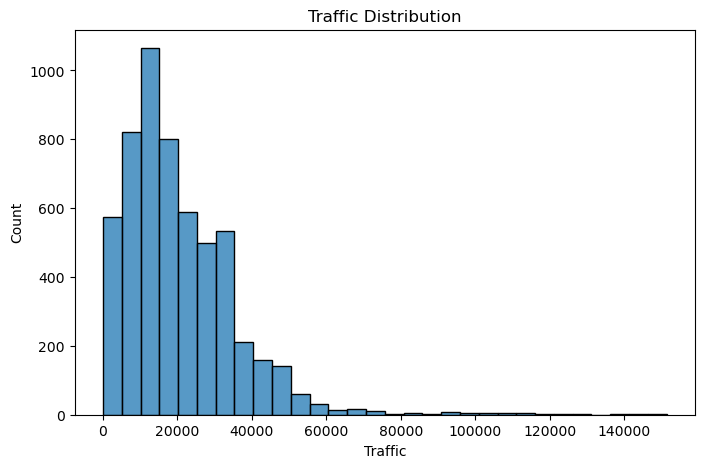

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df["Traffic"], bins=30)

plt.title("Traffic Distribution")

plt.show()

### Refrigerator Capacity vs Sales

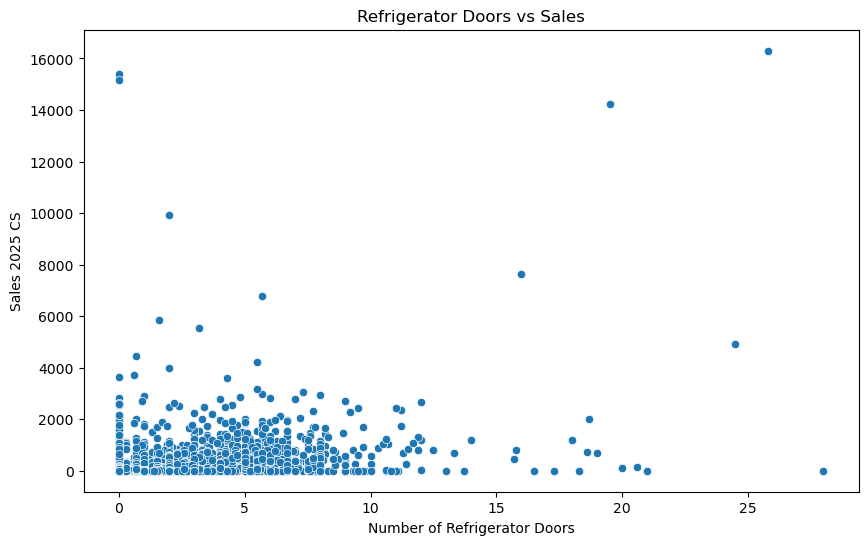

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["# of doors"],
    y=df["Sales 2025 CS"]
)

plt.title("Refrigerator Doors vs Sales")

plt.xlabel("Number of Refrigerator Doors")
plt.ylabel("Sales 2025 CS")

plt.show()

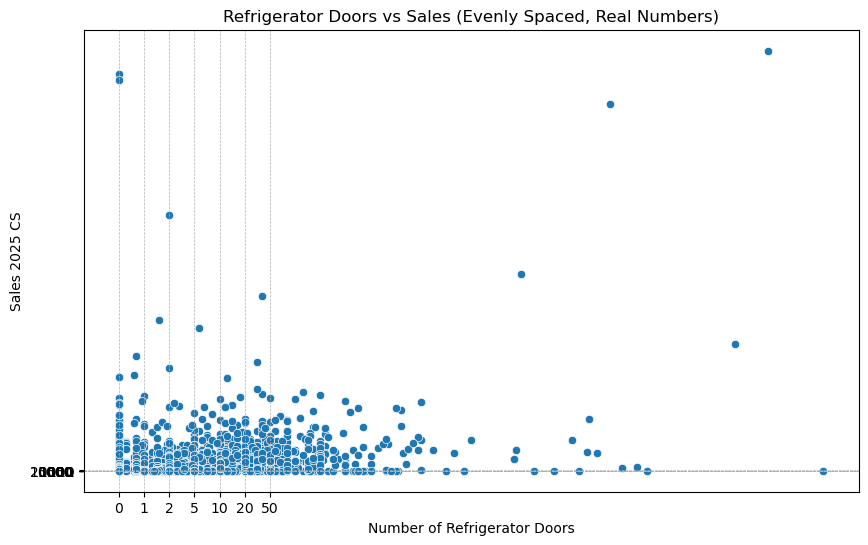

In [46]:
plt.figure(figsize=(10,6))

# Custom ticks
x_ticks = [0, 1, 2, 5, 10, 20, 50]
y_ticks = [0, 1, 10, 50, 100, 500, 1000, 5000, 10000, 20000]




# Покажи реалните стойности като етикети
plt.xticks(range(len(x_ticks)), x_ticks)
plt.yticks(range(len(y_ticks)), y_ticks)

plt.xlabel("Number of Refrigerator Doors")
plt.ylabel("Sales 2025 CS")
plt.title("Refrigerator Doors vs Sales (Evenly Spaced, Real Numbers)")
plt.grid(True, linestyle="--", linewidth=0.5)
sns.scatterplot(
    x=df["# of doors"],
    y=df["Sales 2025 CS"]
)
plt.show()

### Traffic vs Sales

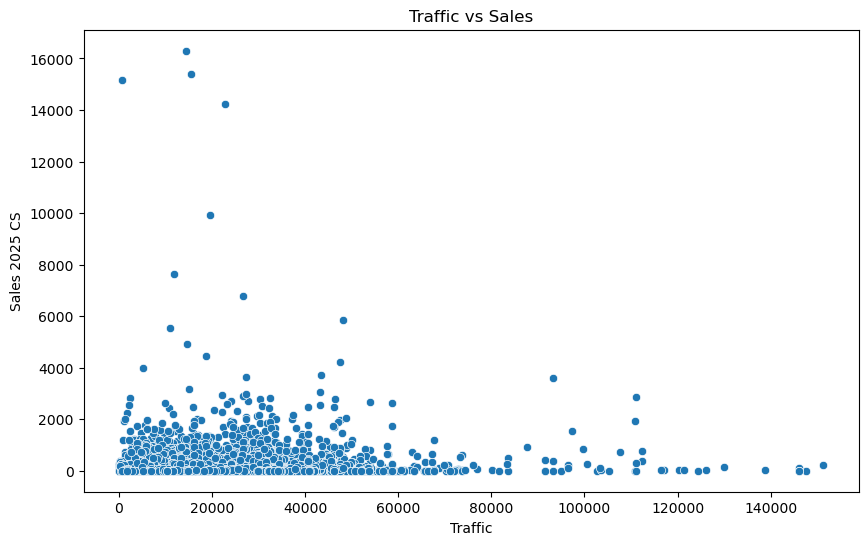

In [8]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Traffic"],
    y=df["Sales 2025 CS"]
)

plt.title("Traffic vs Sales")

plt.show()

### Equipment Impact

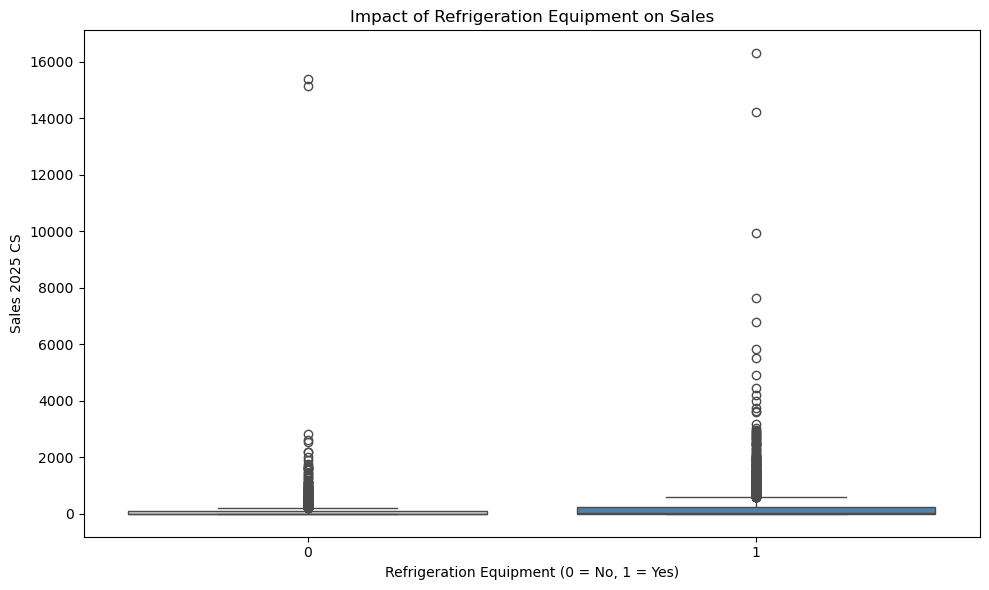

In [9]:
plt.figure(figsize=(10,6))

ax = sns.boxplot(
    x="Equipment (Y/N)",
    y="Sales 2025 CS",
    data=df,
    hue="Equipment (Y/N)",
    palette=["lightgray", "steelblue"]
)

ax.get_legend().remove()

plt.title("Impact of Refrigeration Equipment on Sales")
plt.xlabel("Refrigeration Equipment (0 = No, 1 = Yes)")
plt.ylabel("Sales 2025 CS")

plt.tight_layout()
plt.show()

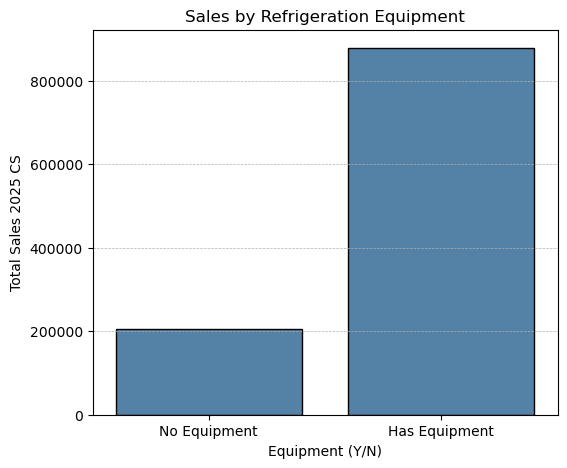

In [58]:
sales_by_equipment = df.groupby("Equipment (Y/N)")["Sales 2025 CS"].sum().reset_index()

plt.figure(figsize=(6,5))

sns.barplot(
    data=sales_by_equipment,
    x="Equipment (Y/N)",
    y="Sales 2025 CS",
    color='steelblue',
    edgecolor='black'
)

plt.xticks([0,1], ["No Equipment", "Has Equipment"])
plt.ylabel("Total Sales 2025 CS")
plt.title("Sales by Refrigeration Equipment")
plt.grid(axis='y', linestyle="--", linewidth=0.5)
plt.show()

The table shows the total sales for customers with and without refrigeration equipment.  
From the visualization, it is clear that outlets with a refrigerator (`Has Equipment`)
generate significantly higher sales compared to those without (`No Equipment`).  
This confirms that having refrigeration equipment is a key factor in boosting seasonal customer sales.

## Correlation Analysis

To better understand the relationships between the key variables, a correlation matrix is computed.

This helps identify which factors are most strongly related to sales performance.

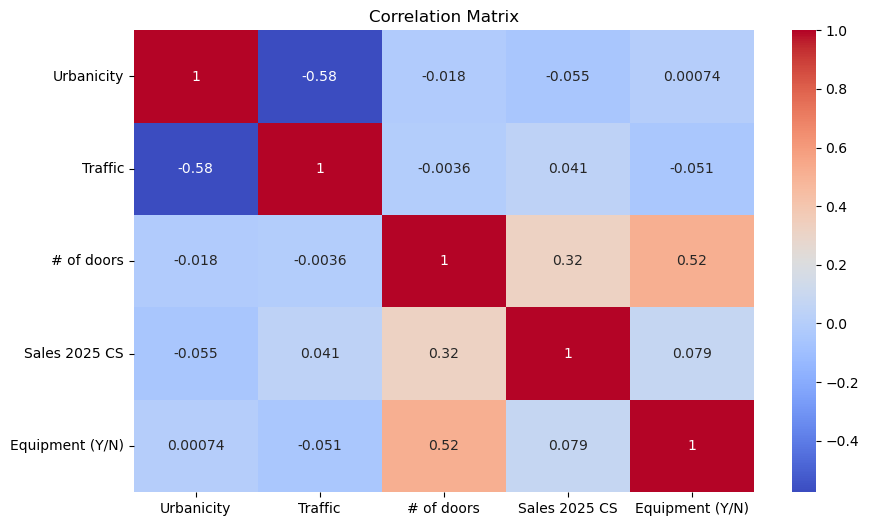

In [10]:
plt.figure(figsize=(10,6))

corr = df[[
    "Urbanicity",
    "Traffic",
    "# of doors",
    "Sales 2025 CS",
    "Equipment (Y/N)"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Feature Selection

For clustering analysis we select variables that influence sales potential:

Urbanicity – level of urbanization  
Traffic – potential customer flow  
Equipment – presence of refrigeration equipment  
Number of refrigerator doors – refrigeration capacity  
Sales – historical sales performance

### Select Features

In [11]:
features = [
    "Urbanicity",
    "Traffic",
    "# of doors",
    "Sales 2025 CS",
    "Equipment (Y/N)"
]

X = df[features]

## Data Scaling

Clustering algorithms rely on distance calculations. Therefore, the data must be standardized so that each variable contributes equally
to the clustering process.

### Scaling Code

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Scaling the data is necessary because K-Means relies on Euclidean distance. Without scaling, features with larger ranges would dominate the distance calculation, leading to biased clusters. StandardScaler standardizes all numeric features to have a mean of
0 and a standard deviation of 1, ensuring each variable contributes equally to the clustering process.

### Sales Potential Score

To better evaluate the sales potential of each customer, a composite score is created.

The score combines three important factors:

Traffic – customer flow near the outlet  
Refrigeration capacity – number of refrigerator doors  
Sales performance – historical sales  

This score helps identify customers with higher business potential.

In [13]:
df["Potential Score"] = (
    df["Traffic"] * 0.4 +
    df["# of doors"] * 0.3 +
    df["Sales 2025 CS"] * 0.3
)

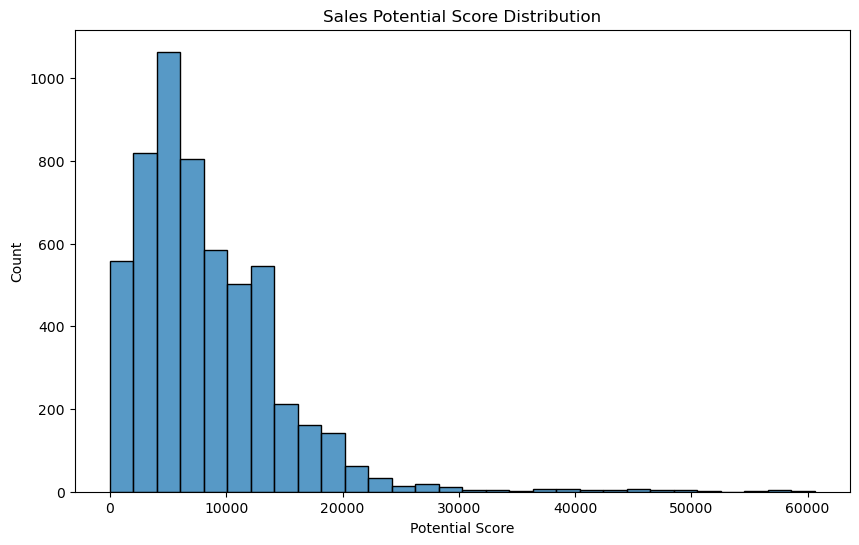

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(df["Potential Score"], bins=30)

plt.title("Sales Potential Score Distribution")

plt.show()

## Determining the Optimal Number of Clusters

### Elbow Method Code

Used to find the optimal number of clusters by plotting WCSS/Within-Cluster Sum of Squares/ vs. number of clusters. The “elbow” point indicates the best k.

WCSS measures the total squared distance between each data point and the centroid of its cluster. It shows how tight or compact the clusters are — lower WCSS indicates that points are closer to their cluster center.


$$
WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \| x - \mu_i \|^2
$$

Where:  
- \($k$\) = number of clusters  
- \($C_i$\) = cluster i  
- \($\mu_i$\) = centroid of cluster i  
- \($x$\) = data point in cluster i

### References for Elbow Method
- Towards Data Science: [How to Determine Optimal Clusters Using Elbow Method](https://towardsdatascience.com/how-to-determine-the-optimal-number-of-clusters-for-k-means-using-elbow-method-6a3e2b1037e6)
- Scikit-learn: [K-Means Clustering Documentation](https://scikit-learn.org/stable/modules/clustering.html#k-means)
- Analytics Vidhya: [Comprehensive Guide to K-Means Clustering](https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/)

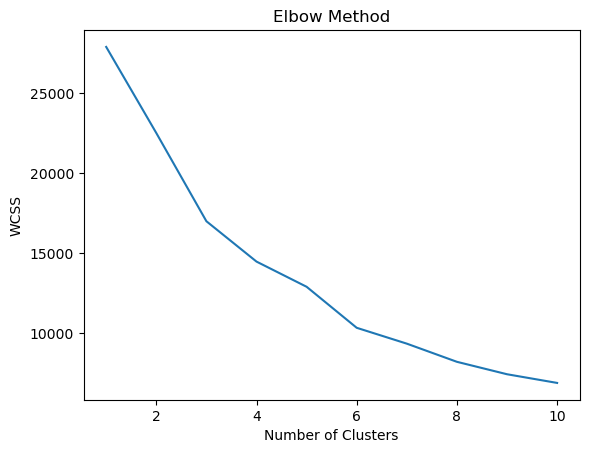

In [15]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

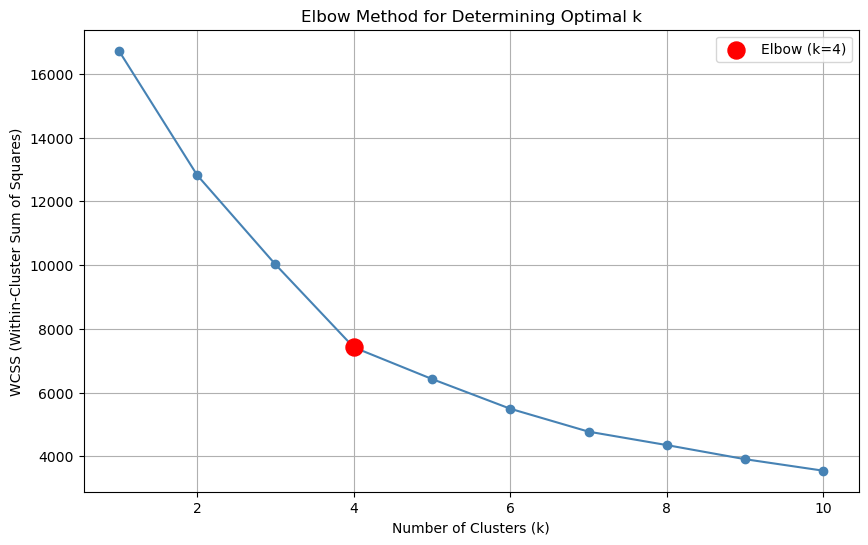

In [16]:
X_demo = df[["Traffic", "# of doors", "Sales 2025 CS"]]

scaler = StandardScaler()
X_scaled_demo = scaler.fit_transform(X_demo)

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_demo)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='steelblue')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Determining Optimal k")
plt.grid(True)

optimal_k = 4
plt.scatter(optimal_k, wcss[optimal_k-1], color='red', s=150, zorder=5, label=f'Elbow (k={optimal_k})')
plt.legend()
plt.show()

Based on the Elbow Method plot, the "elbow" appears at k = 4, suggesting that four clusters balance compactness and interpretability. Additionally, from a business perspective, four segments correspond well to meaningful sales potential categories: Gold, Silver, Bronze, and Iron. This ensures that the clustering results are both statistically valid and actionable.

### Hierarchical Clustering

In addition to K-Means clustering, hierarchical clustering is applied to visualize how customers are grouped based on similarity.

A dendrogram is used to show the hierarchical structure of the clusters.

The dendrogram shows how customers cluster based on similarity. Taller merges indicate more dissimilar groups, helping to estimate the optimal number of clusters.

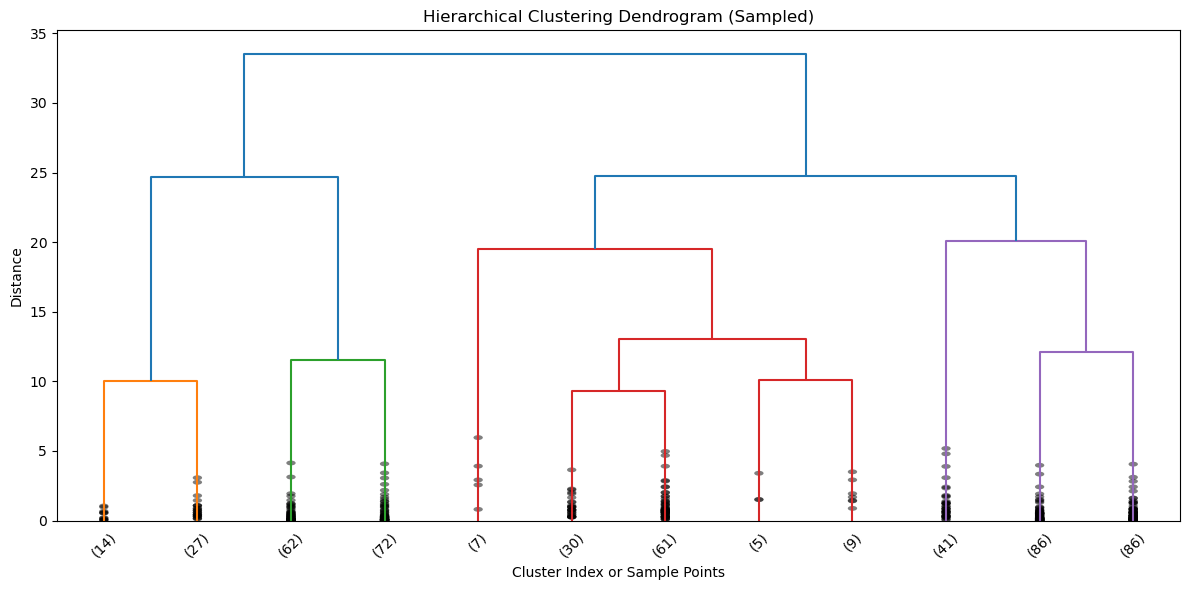

In [17]:
sample_size = 500
df_sample = df.sample(sample_size, random_state=42)
X_sample = df_sample[features]
X_sample_scaled = scaler.fit_transform(X_sample)

linked = linkage(X_sample_scaled, method="ward")

plt.figure(figsize=(12,6))
dendrogram(
    linked,
    truncate_mode='lastp',  
    p=12,                  
    leaf_rotation=45,       
    leaf_font_size=10,      
    show_contracted=True    
)

plt.title("Hierarchical Clustering Dendrogram (Sampled)")
plt.xlabel("Cluster Index or Sample Points")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### K-Means Clustering

K-Means is an unsupervised algorithm that groups data points into **k clusters**. Each cluster has a **centroid** (average of points in the cluster), and points are assigned to the nearest centroid. The algorithm iteratively updates centroids to **minimize WCSS**.

$$
\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x
$$

Where:  
- \( $\mu_i$ \) = centroid of cluster i  
- \( $C_i $\) = cluster i  
- \( $x$ \) = data point in cluster i 

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [19]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.32928231974335553


The silhouette score of 0.329 indicates moderate separation between clusters. This means that while the clusters are reasonably distinct, some data points may lie near the boundaries of adjacent clusters. For business purposes, this level of separation is sufficient to classify customers into the Gold, Silver, Bronze, and Iron segments.

In [20]:
### Convert Clusters to Business Segments

In [21]:
cluster_means = df.groupby("Cluster")["Sales 2025 CS"].mean().sort_values()

segment_map = {
    cluster_means.index[0]:"Iron",
    cluster_means.index[1]:"Bronze",
    cluster_means.index[2]:"Silver",
    cluster_means.index[3]:"Gold"
}

df["Segment_Level"] = df["Cluster"].map(segment_map)

segment_order = ["Gold", "Silver", "Bronze", "Iron"]

df["Segment_Level"] = pd.Categorical(
    df["Segment_Level"],
    categories=segment_order,
    ordered=True
)

### Cluster Visualization

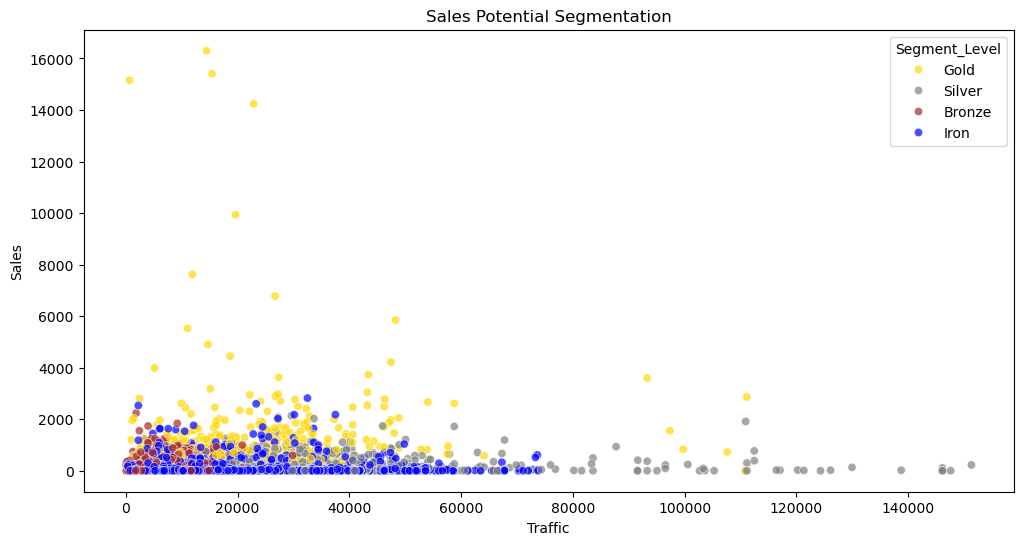

In [22]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x=df["Traffic"],
    y=df["Sales 2025 CS"],
    hue=df["Segment_Level"],
    hue_order=["Gold","Silver","Bronze","Iron"],
    palette=["gold","gray","brown","blue"],
    alpha=0.7
)

plt.title("Sales Potential Segmentation")

plt.xlabel("Traffic")
plt.ylabel("Sales")

plt.show()

### 3D Cluster Visualization

To better visualize the clustering results, a three-dimensional plot is created.

The visualization shows the relationship between traffic levels, refrigerator capacity, and sales performance,
while also displaying the final business segment classification.

X → Traffic
Y → Refrigerator Doors
Z → Sales

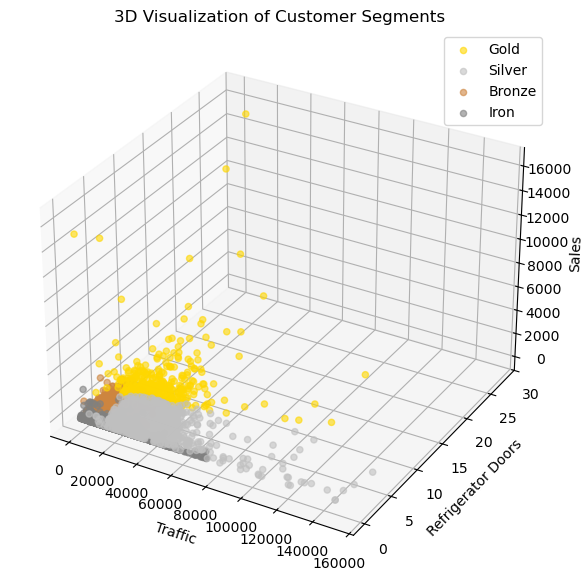

In [23]:
# Define order (ако вече не е дефиниран)
segment_order = ["Gold", "Silver", "Bronze", "Iron"]

# Define color mapping
color_map = {
    "Gold": "gold",
    "Silver": "silver",
    "Bronze": "peru",
    "Iron": "gray"
}

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Plot each segment separately (правилният начин)
for segment in segment_order:
    
    subset = df[df["Segment_Level"] == segment]
    
    ax.scatter(
        subset["Traffic"],
        subset["# of doors"],
        subset["Sales 2025 CS"],
        color=color_map[segment],
        label=segment,
        alpha=0.6
    )

ax.set_xlabel("Traffic")
ax.set_ylabel("Refrigerator Doors")
ax.set_zlabel("Sales")

ax.set_title("3D Visualization of Customer Segments")

ax.legend()

plt.show()

### Cluster Statistics

In [24]:
df.groupby("Segment_Level", observed=False)[features].mean().loc[segment_order]

,Urbanicity,Traffic,# of doors,Sales 2025 CS,Equipment (Y/N)
Segment_Level,,,,,
Gold,3.380054,23900.180836,7.081671,1204.597232,0.994609
Silver,2.497481,31529.305535,1.972292,134.238724,0.991184
Bronze,5.439037,10340.111946,2.043648,129.074904,1.000000
Iron,4.079375,20968.688856,0.000000,103.690811,0.000000


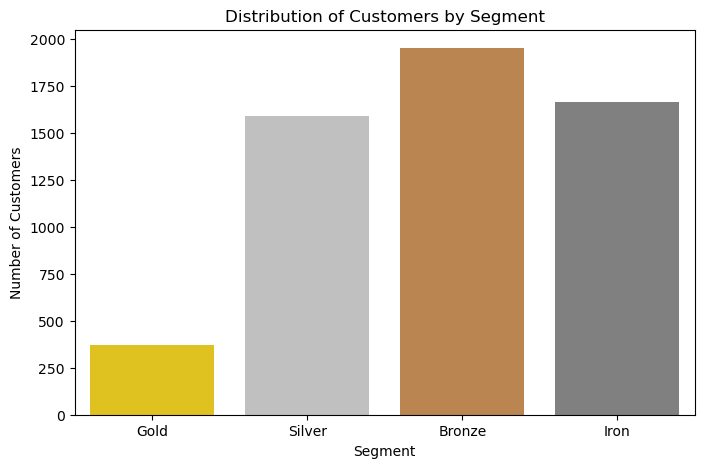

In [25]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="Segment_Level",
    data=df,
    order=["Gold","Silver","Bronze","Iron"],
    hue="Segment_Level",
    palette={
        "Gold":"gold",
        "Silver":"silver",
        "Bronze":"peru",
        "Iron":"gray"
    }
)

plt.title("Distribution of Customers by Segment")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.show()

## Conclusion

This project analyzed the sales potential of seasonal customers such as stores, bars, and restaurants using clustering techniques.

By combining information about traffic levels, refrigeration equipment, refrigerator capacity, urbanization level, and historical sales performance, customers were segmented into four business categories: Gold, Silver, Bronze, and Iron.

The results indicate that refrigeration capacity and customer traffic are strong drivers of sales performance during the summer season.

These insights can help companies optimize equipment allocation, prioritize high-potential customers, and improve sales strategies for seasonal markets.

Future work could include testing additional clustering algorithms, incorporating more business variables, or applying predictive models for sales forecasting.